Saving Lab3.jpg to Lab3.jpg


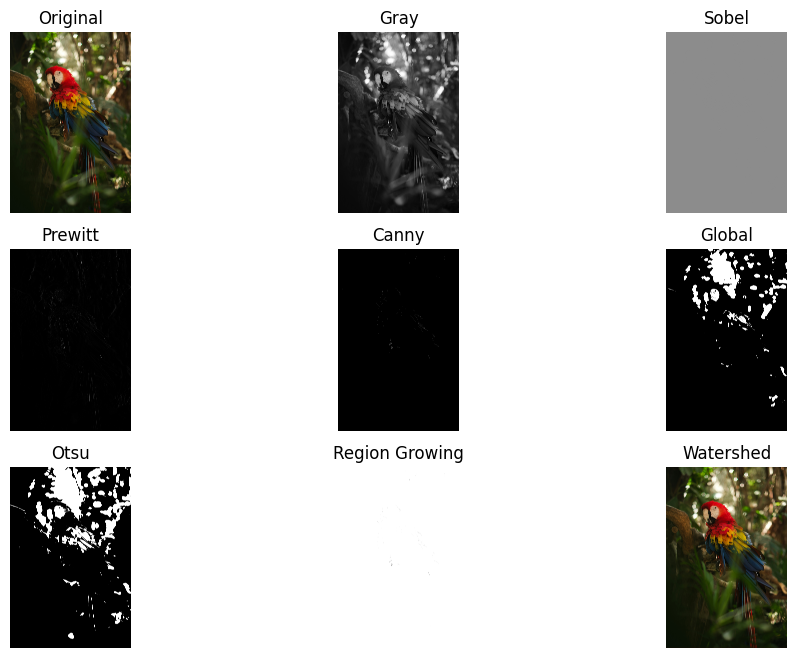

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload Image
uploaded = files.upload()

# Read image
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (5,5), 0)

# 3. Sobel
sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)

# 4. Prewitt
kernel_prewitt = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitt = cv2.filter2D(gray, -1, kernel_prewitt)

# 5. Canny
canny = cv2.Canny(gray, 100, 200)

# 6. Global Threshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 7. Otsu Threshold
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 8. FINAL REGION GROWING
def region_growing(img, seed):
    h, w = img.shape
    visited = np.zeros((h, w), dtype=np.uint8)
    output = np.zeros((h, w), dtype=np.uint8)

    stack = [seed]
    threshold = 25
    output[seed[0], seed[1]] = 255

    while stack:
        x, y = stack.pop()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if visited[nx, ny] == 0:

                        # Compare with current pixel (smooth growth)
                        if abs(int(img[nx, ny]) - int(img[x, y])) < threshold:
                            output[nx, ny] = 255
                            stack.append((nx, ny))

                        visited[nx, ny] = 1

    return output


h, w = gray.shape
seed = (int(h*0.4), int(w*0.4))

region = region_growing(gray, seed)

# 9. Watershed
gray_blur = cv2.GaussianBlur(gray,(5,5),0)
_, th = cv2.threshold(gray_blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernel = np.ones((3,3),np.uint8)
sure_bg = cv2.dilate(th, kernel, iterations=2)

dist = cv2.distanceTransform(th, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.7*dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img.copy(), markers)

watershed = img.copy()
watershed[markers == -1] = [255, 0, 0]

# 10. Display
titles = ["Original","Gray","Sobel","Prewitt","Canny",
          "Global","Otsu","Region Growing","Watershed"]

images = [img, gray, sobel, prewitt, canny,
          thresh, otsu, region, watershed]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(3,3,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.show()